# Prognozowanie ryzyka cukrzycy — Exploratory Data Analysis (EDA)
### Dataset: Pima Indians Diabetes Database

**Cel projektu:** Wykorzystanie sieci neuronowych do przewidywania ryzyka wystąpienia cukrzycy na podstawie danych medycznych pacjentów.

**Narzędzia:** Python, Pandas, NumPy, Seaborn, Matplotlib, Scikit-learn, TensorFlow

---

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100


## 1. Wczytanie danych

Dataset Pima Indians Diabetes Database zawiera dane 768 kobiet z plemienia Pima (Arizona, USA).  

In [4]:
df = pd.read_csv('data/diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Podstawowe informacje o danych

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe().round(2)

## 3. Rozkład zmiennej docelowej (Outcome)

Ile jest przypadków z cukrzycą a ile bez niej?

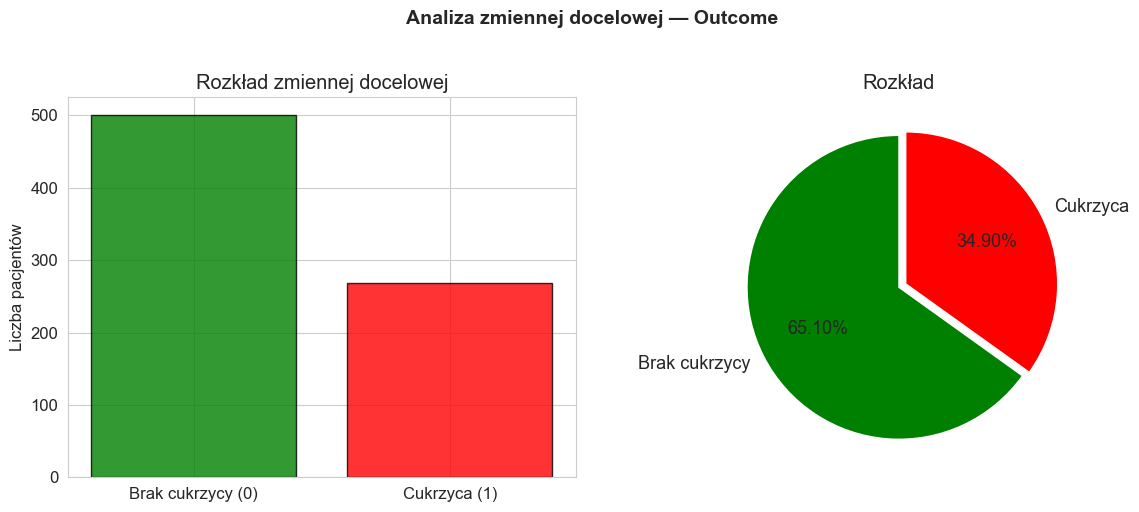

Klasa 0 (brak cukrzycy): 500 (65.1%)
Klasa 1 (cukrzyca): 268 (34.9%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

outcome_counts = df['Outcome'].value_counts()
colors = ['green', 'red']
axes[0].bar(outcome_counts.index, outcome_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Brak cukrzycy (0)', 'Cukrzyca (1)'])
axes[0].set_ylabel('Liczba pacjentów')
axes[0].set_title('Rozkład zmiennej docelowej')

axes[1].pie(outcome_counts.values, labels=['Brak cukrzycy', 'Cukrzyca'], 
            colors=colors, autopct='%.2f%%', startangle=90,
            textprops={'fontsize': 13}, explode=(0, 0.05))
axes[1].set_title('Rozkład')

plt.suptitle('Analiza zmiennej docelowej — Outcome', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Klasa 0 (brak cukrzycy): {outcome_counts[0]} ({outcome_counts[0]/len(df)*100:.1f}%)")
print(f"Klasa 1 (cukrzyca): {outcome_counts[1]} ({outcome_counts[1]/len(df)*100:.1f}%)")

## 4. Analiza brakujących wartości

W tym datasecie brakujące wartości są zakodowane jako **0** w kolumnach, gdzie zero jest fizycznie niemożliwe (np. Glucose, BloodPressure, BMI).

In [9]:
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("ANALIZA WARTOŚCI BRAKUJĄCYCH")
print(f"{'Kolumna':<25} {'Liczba zer':>12} {'Procent':>10}")

zero_counts = {}
for col in zero_columns:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    zero_counts[col] = n_zeros
    print(f"{col:<25} {n_zeros:>12} {pct:>9.1f}%")

print(f"Największy problem: Insulin ({zero_counts['Insulin']/len(df)*100:.1f}% brakujących) i SkinThickness ({zero_counts['SkinThickness']/len(df)*100:.1f}% brakujących)")

ANALIZA WARTOŚCI BRAKUJĄCYCH
Kolumna                     Liczba zer    Procent
Glucose                              5       0.7%
BloodPressure                       35       4.6%
SkinThickness                      227      29.6%
Insulin                            374      48.7%
BMI                                 11       1.4%
Największy problem: Insulin (48.7% brakujących) i SkinThickness (29.6% brakujących)


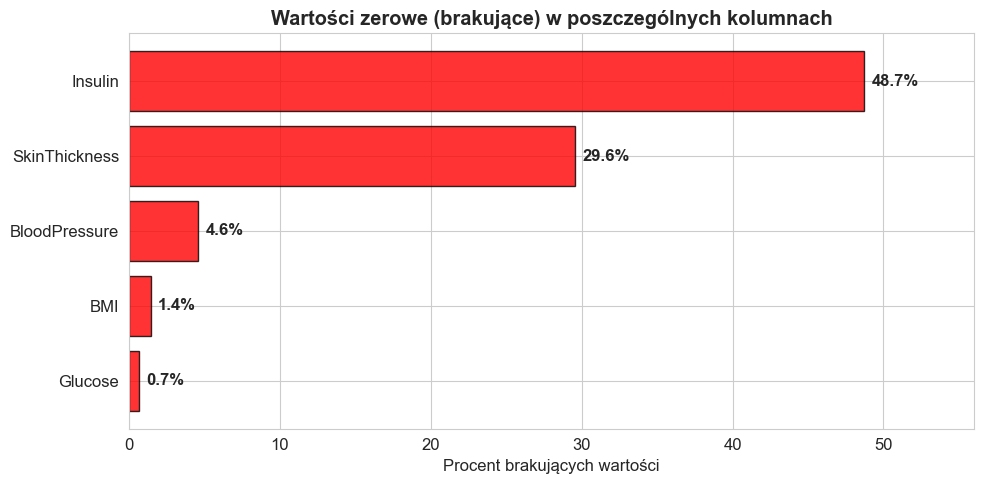

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

missing_data = pd.DataFrame({
    'Kolumna': zero_columns,
    'Brakujące (%)': [(df[col] == 0).sum() / len(df) * 100 for col in zero_columns]
}).sort_values('Brakujące (%)', ascending=True)

bars = ax.barh(missing_data['Kolumna'], missing_data['Brakujące (%)'], 
               color='red', alpha=0.8, edgecolor='black')

for bar, pct in zip(bars, missing_data['Brakujące (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}%', va='center', fontweight='bold')

ax.set_xlabel('Procent brakujących wartości')
ax.set_title('Wartości zerowe (brakujące) w poszczególnych kolumnach', fontweight='bold')
ax.set_xlim(0, max(missing_data['Brakujące (%)']) * 1.15)
plt.tight_layout()
plt.show()

## 5. Rozkłady cech (Features)

Histogramy i wykresy gęstości dla każdej cechy, z podziałem na klasy (zdrowi vs chorzy).

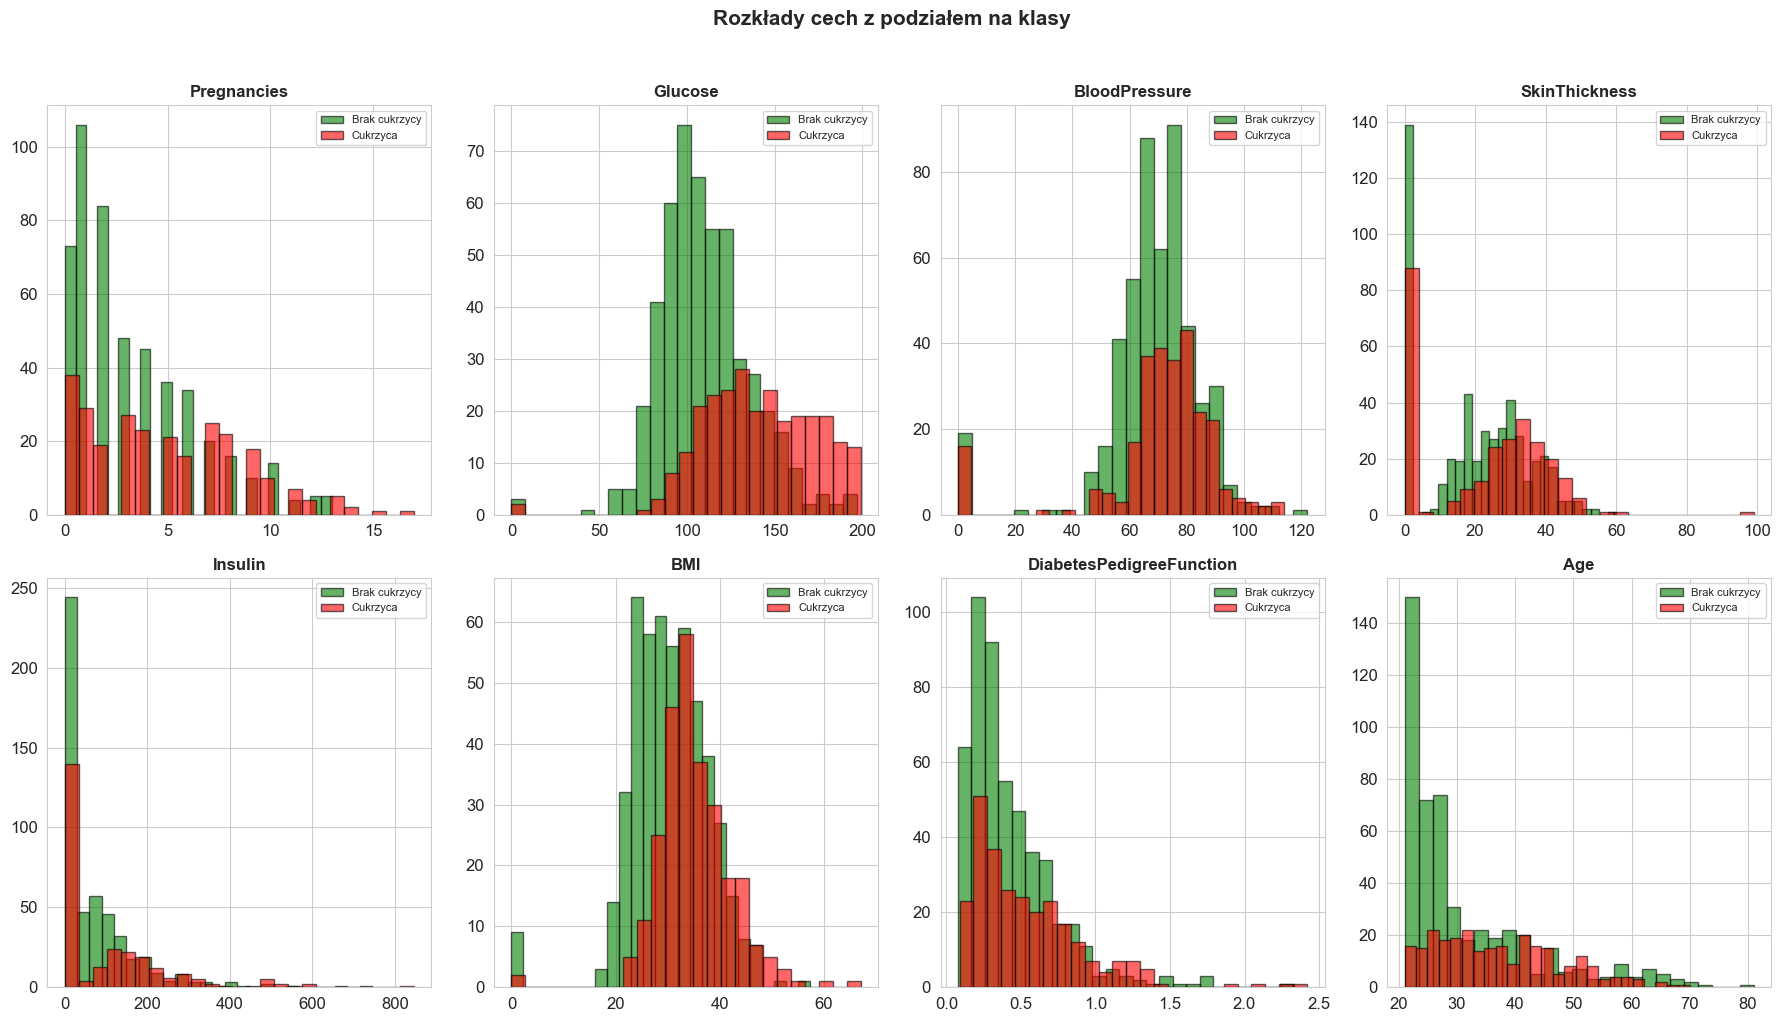

In [ ]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    
    df[df['Outcome'] == 0][col].hist(bins=25, alpha=0.6, color='green', 
                                       label='Brak cukrzycy', ax=ax, edgecolor='black')
    df[df['Outcome'] == 1][col].hist(bins=25, alpha=0.6, color='red', 
                                       label='Cukrzyca', ax=ax, edgecolor='black')
    
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle('Rozkłady cech z podziałem na klasy', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

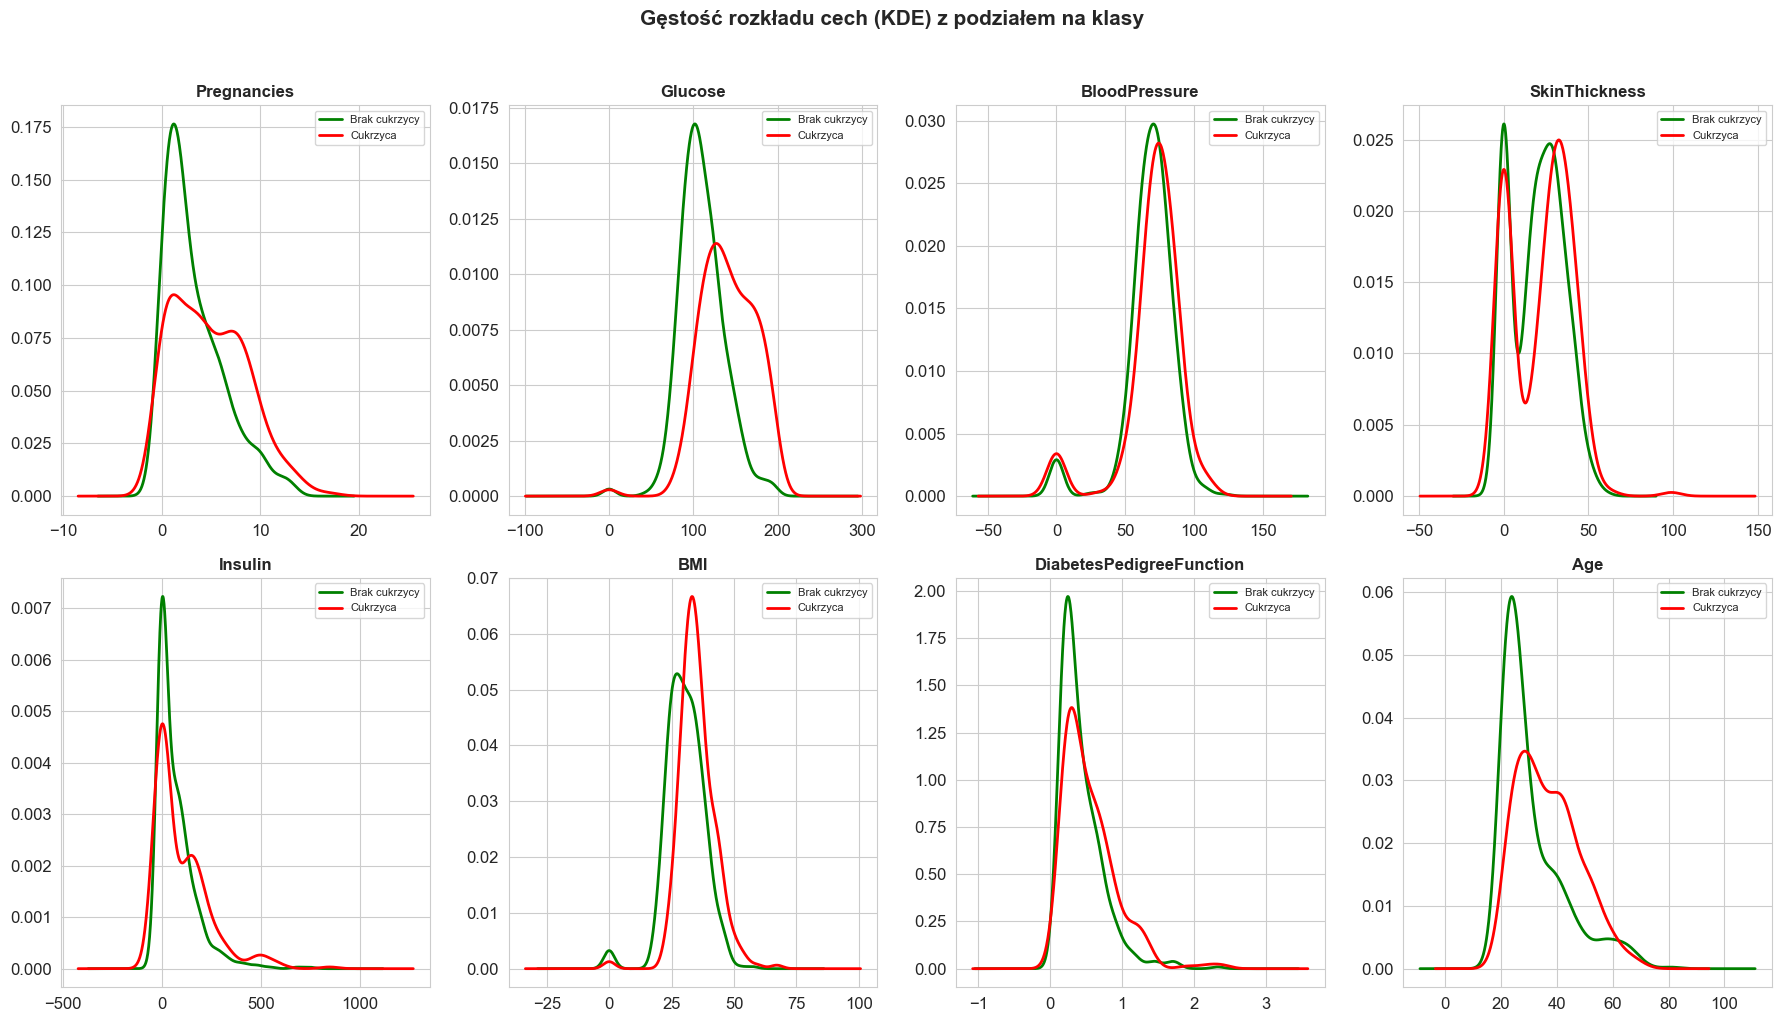

Wnioski:
Glucose - wyraźna separacja między klasami (najsilniejszy predyktor)
BMI - chorzy mają wyższe BMI
Age - starsi pacjenci częściej chorują
Insulin - trudny do interpretacji przez dużo brakujących wartości


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    
    df[df['Outcome'] == 0][col].plot.kde(ax=ax, color='green', label='Brak cukrzycy', linewidth=2)
    df[df['Outcome'] == 1][col].plot.kde(ax=ax, color='red', label='Cukrzyca', linewidth=2)
    
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.legend(fontsize=8)
    ax.set_ylabel('')

plt.suptitle('Gęstość rozkładu cech (KDE) z podziałem na klasy', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Wnioski:")
print("Glucose - wyraźna separacja między klasami (najsilniejszy predyktor)")
print("BMI - chorzy mają wyższe BMI")
print("Age - starsi pacjenci częściej chorują")
print("Insulin - trudny do interpretacji przez dużo brakujących wartości")

## 6. Wykresy pudełkowe (Box Plots) - wykrywanie outlierów

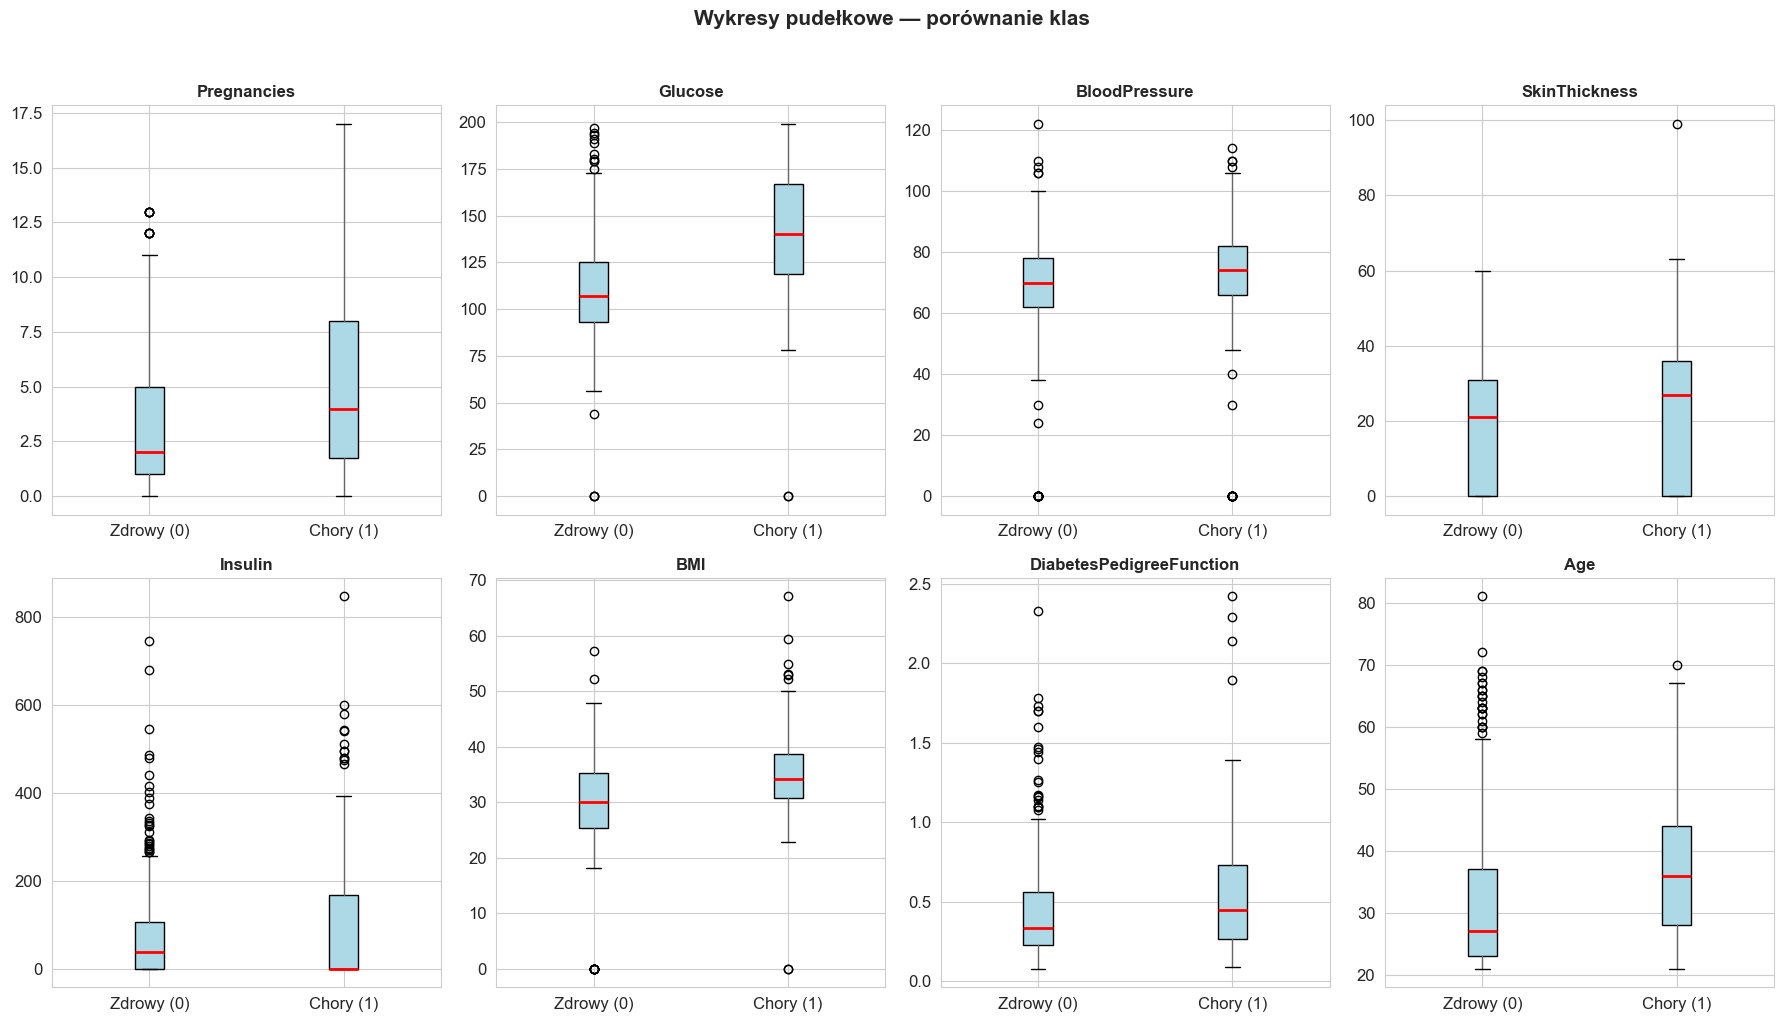

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    df.boxplot(column=col, by='Outcome', ax=ax, 
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='black'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_xticklabels(['Zdrowy (0)', 'Chory (1)'])

plt.suptitle('Wykresy pudełkowe — porównanie klas', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
print("ANALIZA OUTLIERÓW (metoda IQR)")
print(f"{'Kolumna':<25} {'Outlierów':>12} {'Procent':>10}")
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = outliers / len(df) * 100
    print(f"{col:<25} {outliers:>12} {pct:>9.1f}%")

ANALIZA OUTLIERÓW (metoda IQR)
Kolumna                      Outlierów    Procent
Pregnancies                          4       0.5%
Glucose                              5       0.7%
BloodPressure                       45       5.9%
SkinThickness                        1       0.1%
Insulin                             34       4.4%
BMI                                 19       2.5%
DiabetesPedigreeFunction            29       3.8%
Age                                  9       1.2%


## 7. Macierz korelacji

Zależności liniowe między cechami oraz ich korelację ze zmienną docelową.

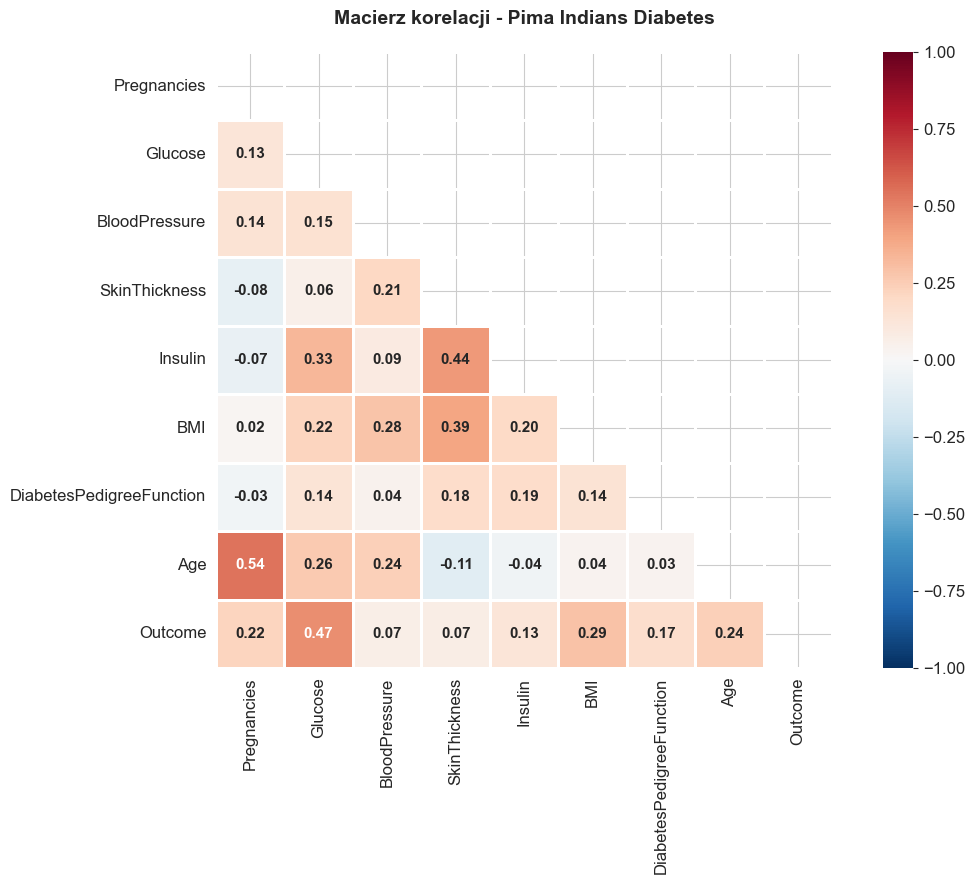

In [21]:
fig, ax = plt.subplots(figsize=(12, 9))

corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, linecolor='white',
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 11, 'fontweight': 'bold'})

ax.set_title('Macierz korelacji - Pima Indians Diabetes', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

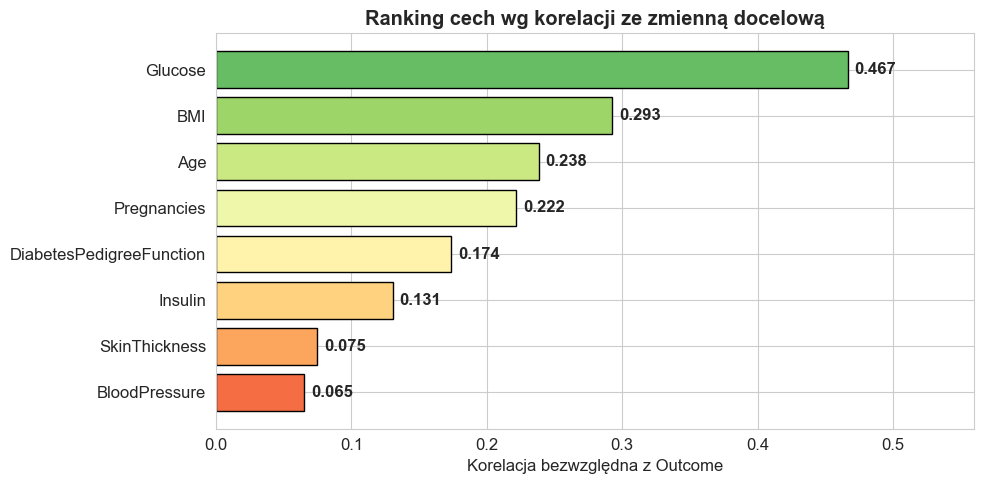

Najsilniejsze predyktory cukrzycy:
Glucose: 0.467
BMI: 0.293
Age: 0.238


In [25]:
target_corr = df.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(target_corr)))
bars = ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1], edgecolor='black')

for bar, val in zip(bars, target_corr.values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontweight='bold')

ax.set_xlabel('Korelacja bezwzględna z Outcome')
ax.set_title('Ranking cech wg korelacji ze zmienną docelową', fontweight='bold')
ax.set_xlim(0, max(target_corr.values) * 1.2)
plt.tight_layout()
plt.show()

print("Najsilniejsze predyktory cukrzycy:")
for feat, corr_val in target_corr.head(3).items():
    print(f"{feat}: {corr_val:.3f}")

## 8. Pairplot - wizualizacja zależności między najważniejszymi cechami

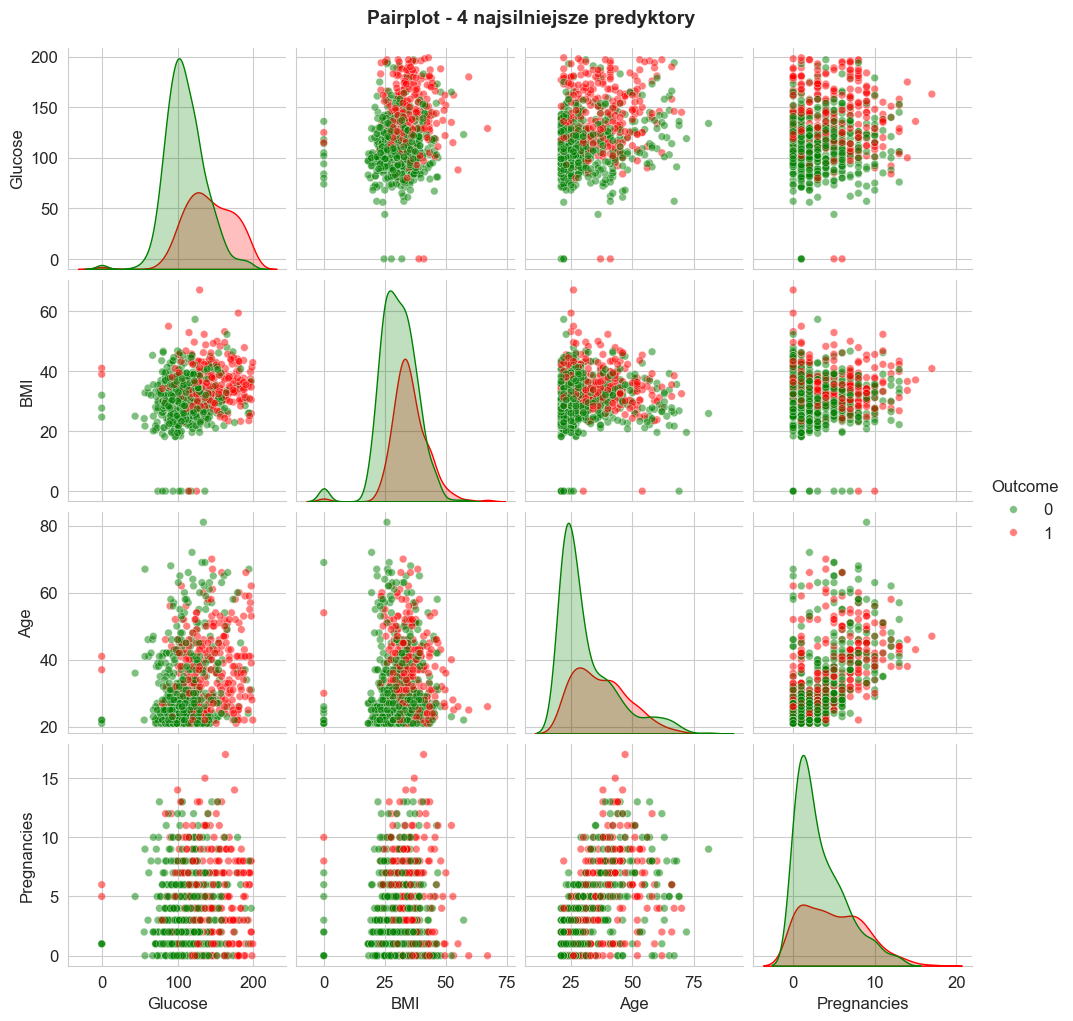

In [29]:
top_features = target_corr.head(4).index.tolist() + ['Outcome']

g = sns.pairplot(df[top_features], hue='Outcome', 
                 palette={0: 'green', 1: 'red'},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30},
                 height=2.5)

g.figure.suptitle('Pairplot - 4 najsilniejsze predyktory', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 9. Analiza statystyczna - porównanie grup

In [33]:
comparison = df.groupby('Outcome')[features].mean().round(2).T
comparison.columns = ['Brak cukrzycy (0)', 'Cukrzyca (1)']
comparison['Różnica (%)'] = ((comparison['Cukrzyca (1)'] - comparison['Brak cukrzycy (0)']) 
                              / comparison['Brak cukrzycy (0)'] * 100).round(1)

print("PORÓWNANIE ŚREDNICH WARTOŚCI CECH MIĘDZY KLASAMI")
print(comparison.to_string())

PORÓWNANIE ŚREDNICH WARTOŚCI CECH MIĘDZY KLASAMI
                          Brak cukrzycy (0)  Cukrzyca (1)  Różnica (%)
Pregnancies                            3.30          4.87         47.6
Glucose                              109.98        141.26         28.4
BloodPressure                         68.18         70.82          3.9
SkinThickness                         19.66         22.16         12.7
Insulin                               68.79        100.34         45.9
BMI                                   30.30         35.14         16.0
DiabetesPedigreeFunction               0.43          0.55         27.9
Age                                   31.19         37.07         18.9
